# Prepare Data for Machine Learning Modeling

## Import Libraries

In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Import Preprocessed Data 

In [16]:
ml_data = pd.read_csv("data/processed_variants_for_EDA.tsv", sep="\t", low_memory=False) 
print(f"Loaded {len(ml_data)} variants.")
display(ml_data.head())

Loaded 1906 variants.


,Hugo_Symbol,Consequence,Variant_Type,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT
0,MAPK1,missense_variant,SNP,0.000000,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0
1,BRCA1,missense_variant,SNP,0.000000,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0
2,BRCA1,missense_variant,SNP,0.000032,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0
3,TP53,missense_variant,SNP,0.000000,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0
4,TP53,missense_variant,SNP,0.000000,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0


## Log-Transform gnomAD_AF

### Visualize before transformation 

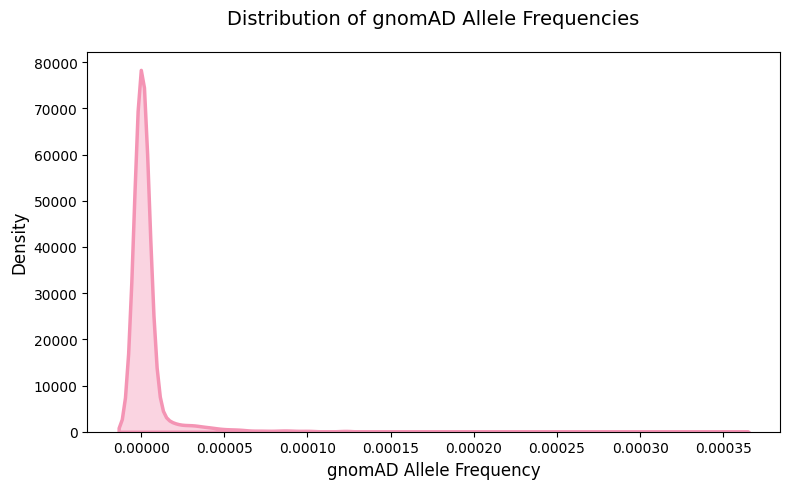

In [17]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF', 
            data=ml_data,
            color="#f494b4",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies', fontsize=14, pad=20)
plt.xlabel('gnomAD Allele Frequency', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.savefig("plots/gnomad_distribution.png", dpi=300)
plt.show()


### Transform data

In [18]:
epsilon = 1e-6
ml_data['gnomAD_AF_log'] = np.log10(ml_data['gnomAD_AF'] + epsilon)

### Visualize after transformation 

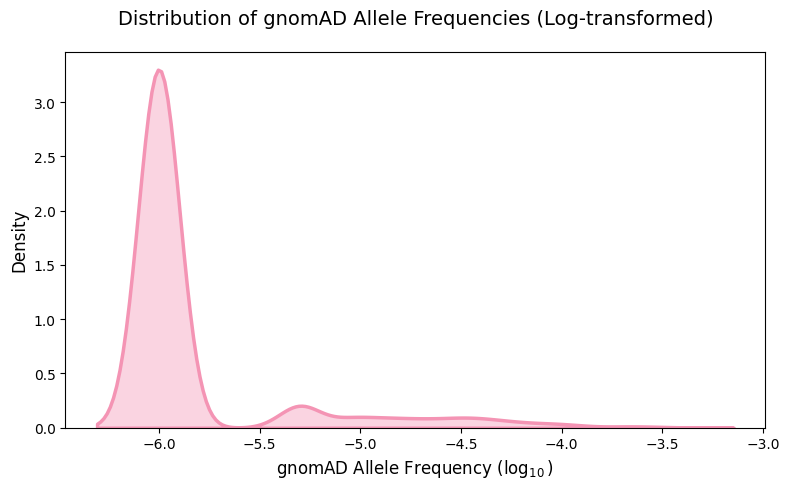

In [19]:
plt.figure(figsize=(8,5)) 

sns.kdeplot(x='gnomAD_AF_log', 
            data=ml_data,
            color="#f494b4",
            fill=True, 
            common_norm=False,
            alpha=0.4,
            linewidth=2.5)

plt.title('Distribution of gnomAD Allele Frequencies (Log-transformed)', fontsize=14, pad=20)
plt.xlabel(r'gnomAD Allele Frequency ($\log_{10}$)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.savefig("plots/gnomad_log_distribution.png", dpi=300)
plt.show()


### Drop gnomAD_AF Column

In [20]:
ml_data = ml_data.drop('gnomAD_AF', axis=1)
display(ml_data.head())

,Hugo_Symbol,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ONCOGENIC,missing_Polyphen,missing_SIFT,gnomAD_AF_log
0,MAPK1,missense_variant,SNP,False,1.000,0.01,False,True,1,False,0,Likely Neutral,0,0,-6.000000
1,BRCA1,missense_variant,SNP,False,0.344,0.00,False,False,0,False,0,Oncogenic,0,0,-6.000000
2,BRCA1,missense_variant,SNP,True,0.026,0.00,False,True,1,False,0,Oncogenic,0,0,-4.482754
3,TP53,missense_variant,SNP,False,0.396,0.12,True,True,1,True,2,Oncogenic,0,0,-6.000000
4,TP53,missense_variant,SNP,False,0.838,0.02,True,True,1,True,1,Oncogenic,0,0,-6.000000


## Map Target to Numbers (1 = "Oncogenic", 0 = "Likely Neutral")

In [21]:
target_map = {'Oncogenic': 1, 'Likely Neutral': 0}
ml_data['TARGET'] = ml_data['ONCOGENIC'].map(target_map)

## Remove Hugo_Symbol from data

In [22]:
# Create gene_groups file 
gene_groups = ml_data["Hugo_Symbol"].copy() 

# remove gene names from data 
ml_data = ml_data.drop(columns=["Hugo_Symbol"])

## Feature engineering 

In [23]:
ml_data['hotspot_x_vartype'] = ml_data['In_Hotspot'].astype(str) + '_' + ml_data['Variant_Type']

print(ml_data['hotspot_x_vartype'].value_counts())

hotspot_x_vartype
False_SNP    1112
True_SNP      386
False_DEL     274
False_INS      57
False_ONP      24
True_DNP       17
False_DNP      17
False_TNP      15
True_TNP        3
True_ONP        1
Name: count, dtype: int64


## Split Data into X (features) and Y (target) 

In [24]:
X = ml_data.drop(['ONCOGENIC', 'TARGET'], axis=1)
y = ml_data['TARGET']

## Split Data into Training and Test

In [25]:
# use stratified sampling for balanced splitting
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(X, y, gene_groups, test_size=0.2, random_state=42, stratify=y)

## Identify Outliers Using Z-score

In [26]:
# Detect outliers using z-scores 

# Compute Z-scores for numeric columns
z_scores = (X_train.select_dtypes(include=[np.number]) - X_train.mean(numeric_only=True)) / X_train.std(numeric_only=True)

# Identify Outliers (absolute Z-score > 3)
outliers = (np.abs(z_scores) > 3)

# Count total outliers
num_outliers = outliers.sum().sum()  # Summing over all columns

print(f"Total number of outliers: {num_outliers}")

Total number of outliers: 100


## Save Processed Dataset for Machine Learning Modeling

In [27]:
# Save feature data 
X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)

# Save target data
y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)

# Save gene group data
group_train.to_csv("data/group_train.csv", index=False) 
group_test.to_csv("data/group_test.csv", index=False)

print("Dataframes successfully saved!🥳") 

Dataframes successfully saved!🥳
